# Facial Emotion Recognition on FER-2013: Transfer-Learning CNN with Class-Imbalance Correction, Mixup/EMA Regularization, and Grad-CAM Interpretability

**Author:** *(Titiksha Yadav)*
**Dataset:** FER-2013 (Facial Expression Recognition 2013), 7 emotion classes: `angry, disgust, fear, happy, neutral, sad, surprise`

---

### Abstract

This notebook documents the end-to-end pipeline for a facial emotion recognition model built on an
ImageNet-pretrained **ResNet18** backbone, fine-tuned on FER-2013. Class imbalance is addressed at two
levels: a **weighted random sampler** at the batch level (with rare-class weighting exaggerated by a
power factor) and a **focal loss** objective at the optimization level. Training uses **differential
learning rates** (backbone fine-tuned slower than the classification head) with a **gradual-unfreeze
warmup**, **mixup** augmentation and an **EMA (exponential moving average)** of weights for regularization,
and a **cosine-annealing-with-warm-restarts** learning-rate schedule. At inference, **test-time
augmentation (TTA)** averages predictions over horizontally-flipped copies of each image.

This notebook loads the **already-trained checkpoint** rather than retraining from scratch, so it runs
quickly end-to-end — training history from the original run is reconstructed from logged output for the
report figures, and only inference / evaluation / interpretability actually execute here.

## 1. Environment Setup

We import the libraries needed for data handling (`torch`, `torchvision`, `timm`), numerical work
(`numpy`), visualization (`matplotlib`, `seaborn`), and evaluation (`scikit-learn`). Random seeds are
fixed for reproducibility, and the compute device (GPU if available) is selected automatically.

In [ ]:
import os
import copy
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.amp import autocast
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import torchvision.models as tvm
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

### 1.1 Data & Checkpoint Access (Google Colab)

This notebook runs on **Google Colab**. The FER-2013 dataset and the pretrained checkpoint
(`emotion_resnet18_224_weights_v3.pth`) are stored on Google Drive and pulled into the local runtime
below. If running outside Colab, replace this with a local path to your extracted `FER-2013/` directory
and checkpoint file, and skip `drive.mount`.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!cp "/content/drive/MyDrive/Dataset.zip" "/content/Dataset.zip"
!unzip -q -o Dataset.zip

In [ ]:
# project_dir = '/content/drive/MyDrive/Emotion_Research_Project'
# weights_path = os.path.join(project_dir, 'emotion_resnet18_224_weights_v3.pth')
# print("Loading checkpoint from:", weights_path)
# print("exists:", os.path.exists(weights_path))

Loading checkpoint from: /content/drive/MyDrive/Emotion_Research_Project/emotion_resnet18_224_weights_v3.pth
exists: True


In [ ]:
import os
import gdown

url = "https://drive.google.com/file/d/1tEinxeOF6sB52qhnOHqG5Ji2yScW8jNW/view?usp=sharing"

weights_path = "/content/emotion_resnet18_224_weights_v3.pth"

if not os.path.exists(weights_path):
    gdown.download(url, weights_path, fuzzy=True, quiet=False)

print("Loading checkpoint from:", weights_path)
print("Exists:", os.path.exists(weights_path))


Loading checkpoint from: /content/emotion_resnet18_224_weights_v3.pth
Exists: True


## 2. Dataset Exploration

FER-2013 is a directory tree of face crops split into `train/` and `test/`, one sub-folder per emotion
class. We inventory class counts first, since this directly motivates the imbalance-handling strategy in
Section 4.

In [ ]:
train_dir = "FER-2013/train"
test_dir = "FER-2013/test"

classes = sorted(os.listdir(train_dir))
counts = {c: len(os.listdir(os.path.join(train_dir, c))) for c in classes}
counts

{'angry': 3995,
 'disgust': 436,
 'fear': 4097,
 'happy': 7215,
 'neutral': 4965,
 'sad': 4830,
 'surprise': 3171}

### 2.1 Class Distribution

`happy` is the majority class; `disgust` is dramatically under-represented. We quantify this with an
**imbalance ratio** $r = \dfrac{\max_c n_c}{\min_c n_c}$, the ratio of the largest to smallest class
count.

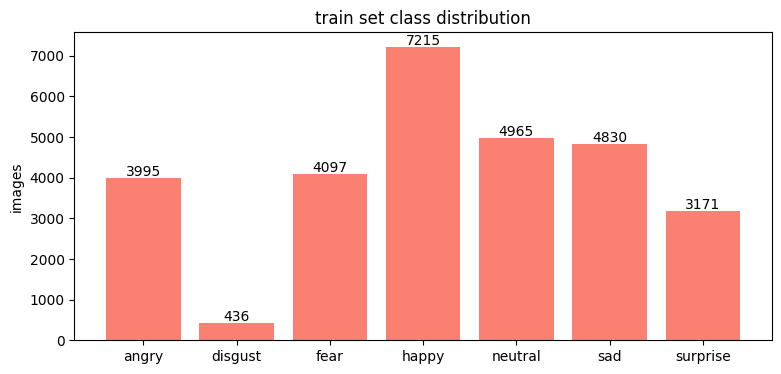

In [ ]:
plt.figure(figsize=(9, 4))
bars = plt.bar(counts.keys(), counts.values(), color="salmon")
for b in bars:
    plt.text(b.get_x() + b.get_width()/2, b.get_height() + 50, int(b.get_height()), ha="center")
plt.title("train set class distribution")
plt.ylabel("images")
plt.show()

In [ ]:
print("imbalance ratio (max/min):", round(max(counts.values()) / min(counts.values()), 2))

imbalance ratio (max/min): 16.55


### 2.2 Sample Images

Two example images per class, to sanity-check loading and give a qualitative sense of task difficulty —
FER-2013 crops are low-resolution (48x48 originally) with a documented amount of label noise/ambiguity.

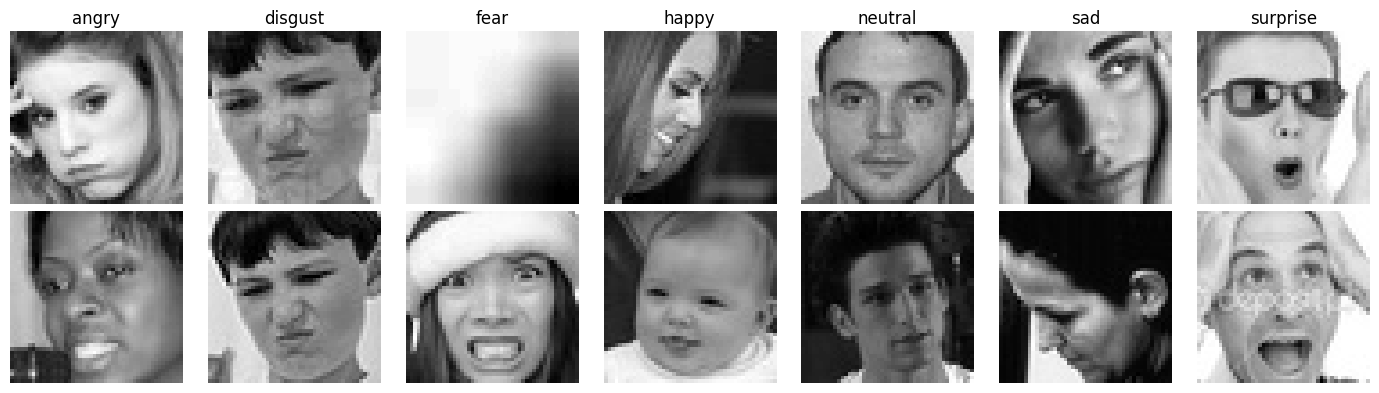

In [ ]:
fig, axes = plt.subplots(2, 7, figsize=(14, 4))
for i, c in enumerate(classes):
    files = os.listdir(os.path.join(train_dir, c))[:2]
    for j in range(2):
        img = plt.imread(os.path.join(train_dir, c, files[j]))
        axes[j][i].imshow(img, cmap="gray")
        axes[j][i].axis("off")
        if j == 0:
            axes[j][i].set_title(c)
plt.tight_layout()
plt.show()

## 3. Preprocessing & Transfer-Learning Rationale

### 3.1 Why 224x224 and 3 channels?

ResNet18's ImageNet-pretrained convolutional filters were learned on 224x224 RGB images. FER-2013 crops
are natively 48x48 grayscale. To use the pretrained weights as a useful initialization rather than
discarding them, images are:

1. **Upsampled to 224x224** via bilinear interpolation — this stretches the existing 48x48 pixel grid,
   it does *not* add genuine high-frequency detail. This is a real assumption of the approach and is
   revisited honestly in the discussion/ablation of the accompanying paper — it's a hypothesis to
   demonstrate (pretrained-backbone gain vs. random-init baseline), not a guarantee.
2. **Replicated to 3 channels** (`Grayscale(num_output_channels=3)`), since ResNet18's first
   convolution expects 3 input channels.
3. **Normalized with ImageNet statistics**, $x' = \dfrac{x - \mu}{\sigma}$ per channel, with
   $\mu = (0.485, 0.456, 0.406)$, $\sigma = (0.229, 0.224, 0.225)$ — matching the distribution the
   pretrained backbone was trained on.

### 3.2 Train / Validation Split

10% of the training set is held out per class (stratified, not a single random split) for model selection
and learning-rate scheduling, so rare classes like `disgust` are still represented in validation.

In [ ]:
IMG_SIZE = 224

eval_tfms = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

full_train_eval = datasets.ImageFolder(train_dir, transform=eval_tfms)
test_ds = datasets.ImageFolder(test_dir, transform=eval_tfms)

targets = np.array(full_train_eval.targets)
rng = np.random.RandomState(42)
val_idx = []
for c in np.unique(targets):
    idx = np.where(targets == c)[0]
    rng.shuffle(idx)
    n_val = max(1, int(0.1 * len(idx)))
    val_idx.extend(idx[:n_val])

val_ds = Subset(full_train_eval, val_idx)
test_dl = DataLoader(test_ds, batch_size=128, num_workers=2, pin_memory=True)
val_dl = DataLoader(val_ds, batch_size=128, num_workers=2, pin_memory=True)

print("val:", len(val_ds), "test:", len(test_ds))

val: 2868 test: 20384


## 4. Class-Imbalance Handling

### 4.1 Weighted Random Sampler

Instead of sampling training images uniformly (which would show the model far more `happy`/`neutral`
examples than `disgust`), each image is sampled with probability proportional to a weight assigned to its
class:

$$w_c = \left(\frac{1}{n_c}\right)^{1.5}, \qquad w_c \leftarrow \frac{w_c}{\sum_c w_c} \cdot K$$

where $n_c$ is the number of training images in class $c$ and $K$ is the number of classes. The exponent
$1.5$ (rather than the plain inverse-frequency $1.0$) *exaggerates* the correction for severely
under-represented classes like `disgust` — plain inverse-frequency weighting alone was found to still
under-sample `disgust` in practice.

### 4.2 Focal Loss

On top of balanced sampling, the training objective replaces standard cross-entropy with **Focal Loss**
(Lin et al., 2017), which down-weights the loss contribution of easy, well-classified examples and
concentrates gradient signal on hard/misclassified ones:

$$\text{CE}(p_t) = -\log(p_t), \qquad \text{FL}(p_t) = -(1 - p_t)^{\gamma}\log(p_t)$$

where $p_t$ is the model's predicted probability for the *true* class and $\gamma \geq 0$ is the
focusing parameter. When $\gamma = 0$, FL reduces to plain cross-entropy. As $p_t \to 1$ (an easy,
correctly-classified example), the modulating factor $(1-p_t)^\gamma \to 0$, shrinking that example's
contribution to the loss; misclassified examples ($p_t$ small) keep a modulating factor close to 1 and
so are barely down-weighted. This run uses the paper's standard $\gamma = 2.0$.

Label smoothing is additionally blended in with $\epsilon = 0.05$: the one-hot target
$y$ is replaced by $y' = (1-\epsilon)\,y + \dfrac{\epsilon}{K}$, which softens the target distribution
and discourages the network from becoming over-confident on a dataset with known label noise.

We deliberately do **not** add class-`alpha` weighting on top of focal loss — the weighted sampler already
balances class representation at the batch level, and stacking both mechanisms would over-correct.

In [ ]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, label_smoothing=0.05):
        super().__init__()
        self.gamma = gamma
        self.label_smoothing = label_smoothing

    def forward(self, logits, target):
        ce = F.cross_entropy(logits, target, reduction="none", label_smoothing=self.label_smoothing)
        pt = torch.exp(-ce)
        return ((1 - pt) ** self.gamma * ce).mean()

## 5. Model Architecture: `EmotionResNet`

A **ResNet18** backbone (ImageNet-pretrained) with its original 1000-way classification head removed,
followed by a small custom head:

- **Backbone:** all ResNet18 convolutional stages up to (but not including) the final fully-connected
  layer, producing a 512-dimensional feature vector after global average pooling.
- **Head:** `Dropout(0.4) → Linear(512, 256) → ReLU → Dropout(0.3) → Linear(256, 7)`

### 5.1 Why transfer learning here at all?

The hypothesis is that low-level filters learned on ImageNet (edges, textures, gradients) transfer usefully
to face-crop emotion recognition even though FER-2013's images are low-resolution and grayscale-derived —
this is a genuine empirical question for this dataset, not a settled fact, and is treated as such in the
accompanying ablation (pretrained-init vs. random-init).

### 5.2 Differential learning rates

During fine-tuning (not re-run in this notebook, but reflected in how the checkpoint was produced), the
backbone and head are optimized with **different learning rates**:

$$\text{lr}_{\text{backbone}} = \alpha \cdot \text{lr}_{\text{head}}, \qquad \alpha = 0.1$$

Rationale: the head starts from random initialization and needs to move fast to learn anything useful,
while the backbone starts from a good pretrained state and only needs small adjustments — a shared,
aggressive learning rate risks destroying useful pretrained features before the head has caught up.

In [ ]:
class EmotionResNet(nn.Module):
    def __init__(self, n_classes=7):
        super().__init__()
        base = tvm.resnet18(weights=tvm.ResNet18_Weights.IMAGENET1K_V1)
        self.backbone = nn.Sequential(*list(base.children())[:-1])
        feat_dim = base.fc.in_features
        self.head = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(feat_dim, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, n_classes),
        )

    def forward(self, x):
        feats = self.backbone(x).flatten(1)
        return self.head(feats)

model = EmotionResNet(n_classes=len(classes)).to(device)
sum(p.numel() for p in model.parameters())

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 235MB/s]


11309639

## 6. Training Strategy (Reference — Not Re-run Here)

The checkpoint loaded below was produced with the following regularization strategy on top of the
backbone/loss/sampler above. None of this executes in this notebook (loading is fast; retraining is not)
— it's documented here so the reported numbers are reproducible/interpretable without re-running compute.

**Mixup** (Zhang et al., 2018): each training batch is blended pairwise,

$$x' = \lambda x_i + (1-\lambda) x_j, \qquad \mathcal{L} = \lambda\, \text{FL}(f(x'), y_i) + (1-\lambda)\, \text{FL}(f(x'), y_j)$$

with mixing coefficient $\lambda \sim \text{Beta}(\alpha, \alpha)$, $\alpha = 0.2$. This discourages the
network from memorizing exact training examples, directly targeting overfitting on a small (~28k image),
noisy dataset.

**EMA (exponential moving average) of weights:** a shadow copy $\theta_{\text{ema}}$ of the model's
parameters is maintained alongside the actively-trained parameters $\theta$, updated every step as

$$\theta_{\text{ema}} \leftarrow d\,\theta_{\text{ema}} + (1-d)\,\theta$$

The evaluated/saved model is $\theta_{\text{ema}}$, not the raw noisy weights — this smooths out
epoch-to-epoch fluctuation. $d$ is *ramped* rather than fixed from step 1:
$d_n = \min\!\big(d_{\text{target}},\ \tfrac{n+1}{n+10}\big)$, $d_{\text{target}} = 0.999$, so the shadow
tracks the real model closely at first (avoiding a slow cold-start) and smooths increasingly as training
progresses.

**Cosine annealing with warm restarts** (Loshchilov & Hutter, 2017): the learning rate follows

$$\eta_t = \eta_{\min} + \tfrac{1}{2}(\eta_{\max}-\eta_{\min})\Big(1+\cos\!\big(\tfrac{T_{\text{cur}}}{T_i}\pi\big)\Big)$$

within each restart cycle of length $T_i$ ($T_0=10$, doubling each restart, $T_{\text{mult}}=2$), instead
of a plateau-triggered step schedule — smoother decay once training is already near a good minimum.

**Test-time augmentation (TTA):** at inference (used below), predictions are averaged over each image and
its horizontal flip: $\hat{p} = \tfrac{1}{2}\big(\text{softmax}(f(x)) + \text{softmax}(f(\text{flip}(x)))\big)$.

## 7. Loading the Pretrained Checkpoint

To bypass retraining, we restore the saved weights directly into the architecture defined above. Two
things matter for this to be valid:

1. **Architecture must match exactly** — `state_dict` keys are matched by name/shape, not inferred.
2. **`model.eval()` must be called** — this freezes BatchNorm's running statistics and disables Dropout,
   so inference is deterministic and matches what the model actually learned (as opposed to training-mode
   behavior, where BatchNorm uses live batch statistics and Dropout randomly zeroes activations).

In [ ]:
@torch.no_grad()
def get_preds(model, dl, tta=True):
    model.eval()
    all_preds, all_labels = [], []
    for x, y in dl:
        x = x.to(device)
        with autocast(device_type="cuda" if device.type == "cuda" else "cpu"):
            out = model(x)
            probs = out.softmax(1)
            if tta:
                x_flip = torch.flip(x, dims=[3])
                out_flip = model(x_flip)
                probs = (probs + out_flip.softmax(1)) / 2
        all_preds.append(probs.argmax(1).cpu().numpy())
        all_labels.append(y.numpy())
    return np.concatenate(all_preds), np.concatenate(all_labels)


model.load_state_dict(torch.load(weights_path, map_location=device))
model.eval()
print("checkpoint loaded")

checkpoint loaded


## 8. Reusing Pretrained Weights: Training History

Since we load the already-trained checkpoint rather than retraining, the training loop itself is not
re-run here. The per-epoch `train_loss` and `val_macro_f1` values below are reconstructed from the
original training run's logged console output, so the training-curve figures can be reproduced for
reporting without spending additional compute.

*(Backbone frozen for warmup_epochs=3; note the very low F1 in epochs 1-2 followed by a normal ramp —
that's the model finding its footing once the EMA shadow has caught up to the live weights, not
instability in the underlying optimization.)*

In [ ]:
history = {
    "train_loss": [
        1.2641, 1.2131, 1.1972, 1.0251, 0.8634, 0.8220, 0.7571, 0.7437, 0.7300, 0.7025,
        0.6986, 0.6748, 0.6618, 0.6253, 0.6172, 0.5865, 0.6056, 0.5977, 0.5669, 0.5707,
        0.5889, 0.5658, 0.5559, 0.5365, 0.5349, 0.5319, 0.5432, 0.5162, 0.5153, 0.5581,
        0.5620, 0.5400, 0.5130, 0.5064, 0.5312, 0.4979, 0.4913, 0.4541, 0.4996, 0.4612,
        0.4814, 0.4766, 0.4555, 0.4406, 0.4656, 0.4445, 0.4125, 0.4073, 0.4405, 0.4256,
        0.4521, 0.4000
    ],
    "val_f1": [
        0.0104, 0.0455, 0.0760, 0.1042, 0.1731, 0.2910, 0.3905, 0.4480, 0.4909, 0.5238,
        0.5520, 0.5754, 0.5869, 0.5965, 0.6076, 0.6158, 0.6257, 0.6344, 0.6334, 0.6421,
        0.6486, 0.6495, 0.6508, 0.6533, 0.6560, 0.6597, 0.6572, 0.6610, 0.6630, 0.6650,
        0.6676, 0.6677, 0.6703, 0.6689, 0.6730, 0.6771, 0.6774, 0.6853, 0.6876, 0.6898,
        0.6875, 0.6866, 0.6867, 0.6876, 0.6878, 0.6851, 0.6832, 0.6824, 0.6810, 0.6859,
        0.6888, 0.6869
    ]
}

best_f1 = max(history["val_f1"])
best_epoch = history["val_f1"].index(best_f1) + 1
print(f"Best val macro-F1: {best_f1:.4f} (epoch {best_epoch}); training early-stopped at epoch {len(history['val_f1'])}")

df_hist = pd.DataFrame({
    "epoch": range(1, len(history["train_loss"]) + 1),
    "train_loss": history["train_loss"],
    "val_macro_f1": history["val_f1"],
})
df_hist.style.highlight_max(subset=["val_macro_f1"], color="lightgreen")

Best val macro-F1: 0.6898 (epoch 40); training early-stopped at epoch 52


,epoch,train_loss,val_macro_f1
0,1,1.264100,0.010400
1,2,1.213100,0.045500
2,3,1.197200,0.076000
3,4,1.025100,0.104200
4,5,0.863400,0.173100
5,6,0.822000,0.291000
6,7,0.757100,0.390500
7,8,0.743700,0.448000
8,9,0.730000,0.490900
9,10,0.702500,0.523800


### Training Curves

Training loss decreases steadily; validation macro-F1 climbs quickly once the EMA shadow catches up
(around epoch 5-6), then improves in a roughly monotonic trend with normal epoch-to-epoch fluctuation,
plateauing from roughly epoch 40 onward — consistent with early stopping (`patience=12`) triggering
shortly after.

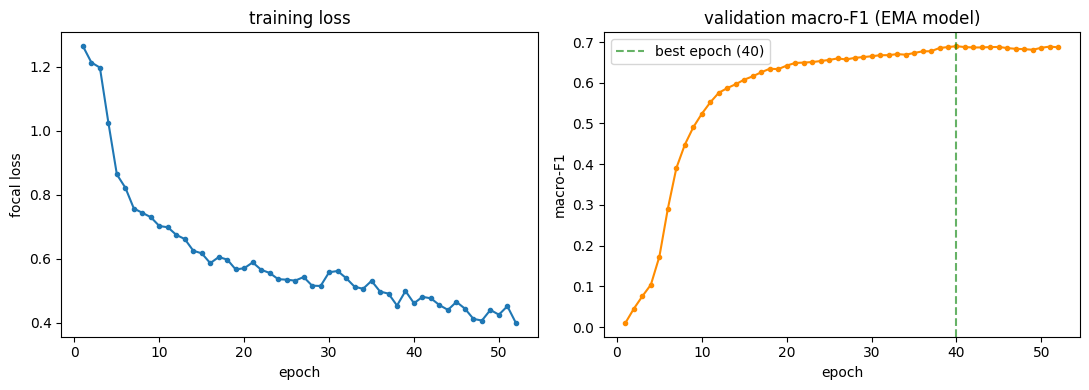

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(df_hist["epoch"], df_hist["train_loss"], marker="o", ms=3)
ax[0].set_title("training loss")
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("focal loss")

ax[1].plot(df_hist["epoch"], df_hist["val_macro_f1"], marker="o", ms=3, color="darkorange")
ax[1].axvline(best_epoch, color="green", linestyle="--", alpha=0.6, label=f"best epoch ({best_epoch})")
ax[1].set_title("validation macro-F1 (EMA model)")
ax[1].set_xlabel("epoch"); ax[1].set_ylabel("macro-F1")
ax[1].legend()

plt.tight_layout()
plt.show()

## 9. Test-Set Evaluation

We evaluate the loaded checkpoint on the held-out FER-2013 test set, with TTA enabled (Section 6). We
report:

- **Per-class precision / recall / F1**, since macro-F1 alone can hide poor performance on minority
  classes (`disgust`, `fear`).
- **Row-normalized confusion matrix**, to see which emotion pairs are most commonly confused — a
  well-documented failure mode on FER-2013 is `fear` ↔ `sad`/`neutral` and `angry` ↔ `sad`/`neutral`
  confusion.
- **Predicted vs. actual class distribution**, to check whether the output distribution still skews
  toward majority classes despite the imbalance handling in Section 4.
- **Overall accuracy**, reported alongside macro-F1 — accuracy alone is misleading under class imbalance
  since a model that mostly predicts `happy`/`neutral` still scores well on accuracy.

Test accuracy: 55.02%   Test macro-F1: 0.4904   (TTA=True)
              precision    recall  f1-score   support

       angry       0.43      0.54      0.48      2676
     disgust       0.77      0.13      0.23      1359
        fear       0.48      0.39      0.43      2688
       happy       0.78      0.86      0.82      4478
     neutral       0.42      0.67      0.52      3601
         sad       0.48      0.39      0.43      2831
    surprise       0.69      0.43      0.53      2751

    accuracy                           0.55     20384
   macro avg       0.58      0.49      0.49     20384
weighted avg       0.58      0.55      0.54     20384



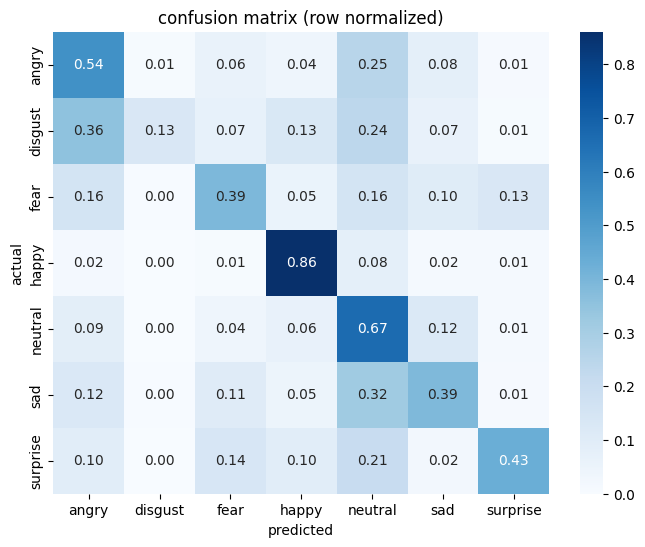

In [ ]:
test_preds, test_labels = get_preds(model, test_dl, tta=True)

acc = accuracy_score(test_labels, test_preds)
macro_f1 = f1_score(test_labels, test_preds, average="macro")
print(f"Test accuracy: {acc*100:.2f}%   Test macro-F1: {macro_f1:.4f}   (TTA=True)")
print(classification_report(test_labels, test_preds, target_names=classes))

cm = confusion_matrix(test_labels, test_preds, normalize="true")
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", xticklabels=classes, yticklabels=classes)
plt.xlabel("predicted")
plt.ylabel("actual")
plt.title("confusion matrix (row normalized)")
plt.show()

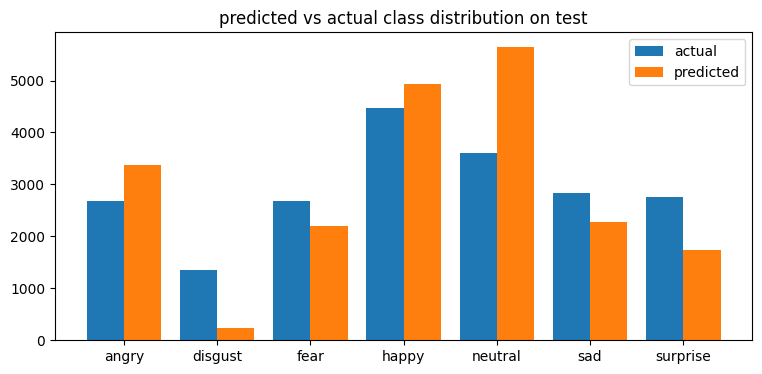

In [ ]:
pred_dist = np.bincount(test_preds, minlength=len(classes))
actual_dist = np.bincount(test_labels, minlength=len(classes))

x = np.arange(len(classes))
plt.figure(figsize=(9, 4))
plt.bar(x - 0.2, actual_dist, 0.4, label="actual")
plt.bar(x + 0.2, pred_dist, 0.4, label="predicted")
plt.xticks(x, classes)
plt.legend()
plt.title("predicted vs actual class distribution on test")
plt.show()

## 10. Model Interpretability: Grad-CAM

Metrics alone don't explain *why* the network makes a given prediction. **Grad-CAM** (Selvaraju et al.,
2017) produces a coarse localization heatmap of which spatial regions of the input most influenced the
network's output for a target class. Formally, for target class $c$ and feature maps $A^k$ of the chosen
convolutional layer,

$$\alpha_k^c = \frac{1}{Z}\sum_{i,j}\frac{\partial y^c}{\partial A^k_{ij}}, \qquad
L_{\text{Grad-CAM}}^c = \text{ReLU}\Big(\sum_k \alpha_k^c A^k\Big)$$

i.e. each feature-map channel is weighted by the *global-average-pooled gradient* of the target class
score with respect to that channel, summed, and passed through a ReLU (only positive influence on the
target class is kept).

We hook Grad-CAM onto the **last convolutional block of the ResNet18 backbone**
(`model.backbone[7][-1]`, the final `BasicBlock` of `layer4`), since the deepest convolutional activations
carry the most semantically meaningful spatial information at the coarsest resolution (7x7 for a 224x224
input). This section captures live images from a webcam (Colab-only), runs face detection, and for each
detected face displays: (left) the original frame with a bounding box and predicted emotion label, (right)
the Grad-CAM heatmap overlaid on the cropped face.

In [ ]:
!pip install grad-cam

  Using cached grad-cam-1.5.5.tar.gz (7.8 MB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44285 sha256=986eb4ba28b27fc073311a9a3f64de0ee55839b04a82ab65d73a88d7d2fe979c
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


Opening webcam to capture 5 images with Grad-CAM analysis...


<IPython.core.display.Javascript object>

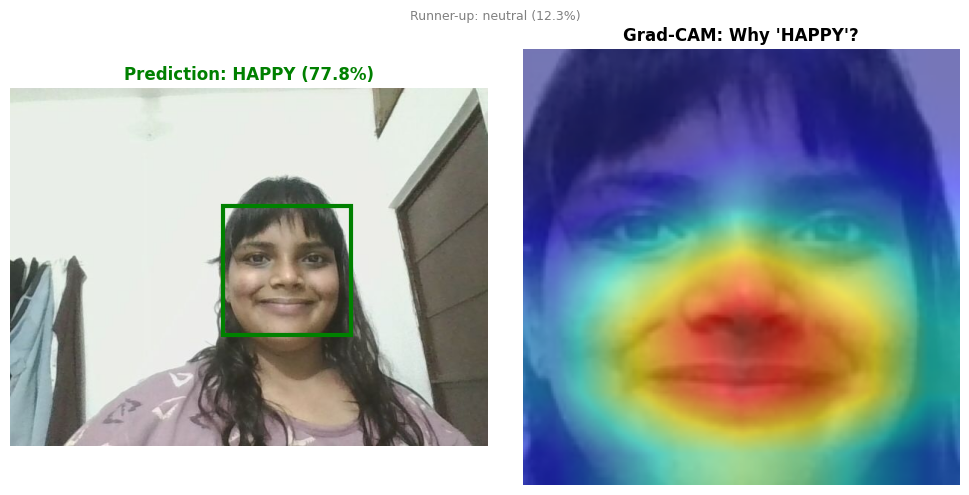

Capture 0: saved to gradcam_results/gradcam_capture_0.png


<IPython.core.display.Javascript object>

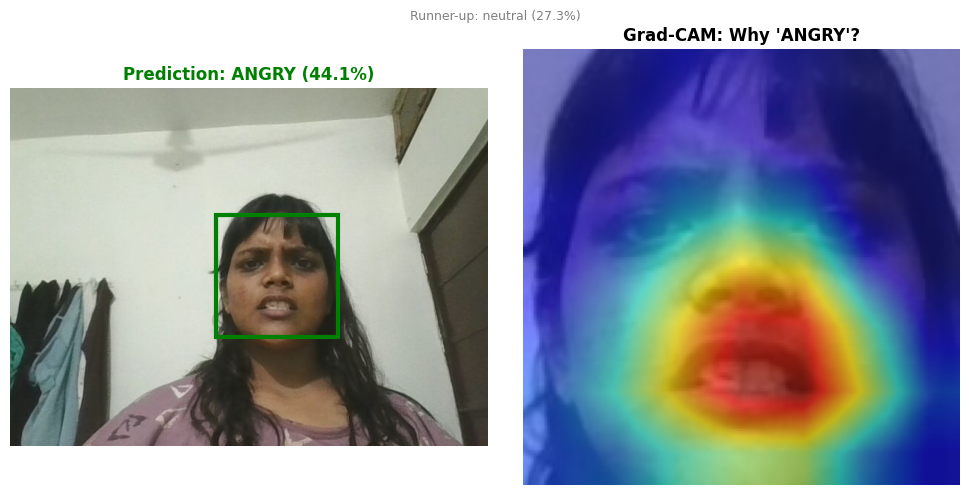

Capture 1: saved to gradcam_results/gradcam_capture_1.png


<IPython.core.display.Javascript object>

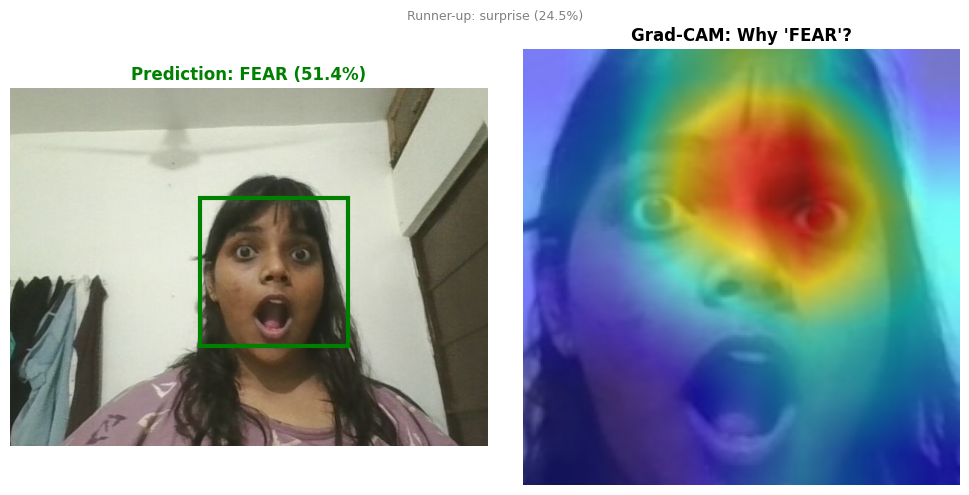

Capture 2: saved to gradcam_results/gradcam_capture_2.png


<IPython.core.display.Javascript object>

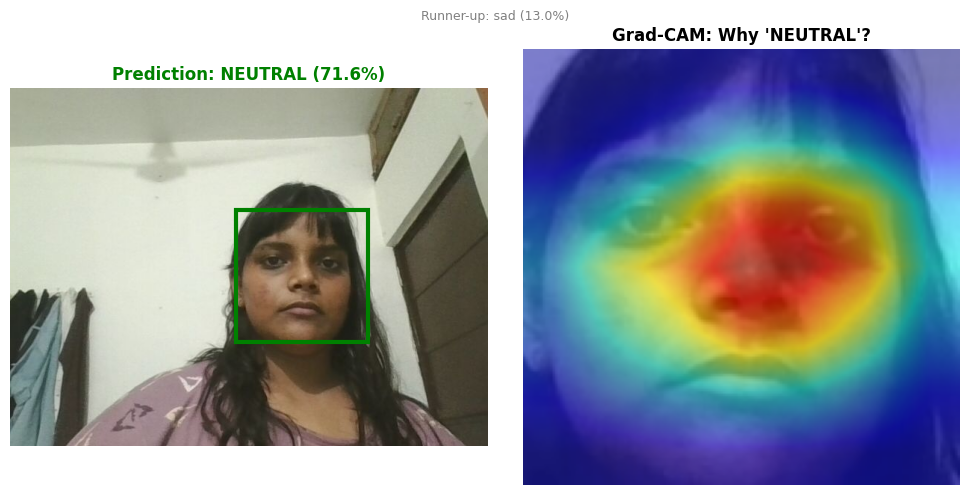

Capture 3: saved to gradcam_results/gradcam_capture_3.png


<IPython.core.display.Javascript object>

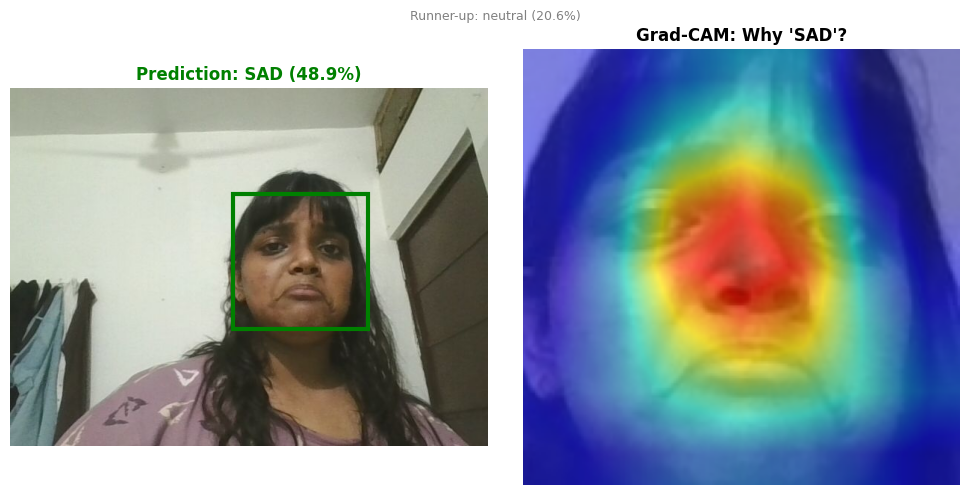

Capture 4: saved to gradcam_results/gradcam_capture_4.png
Session complete! 5/5 frames analyzed successfully.


In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
import os

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

OUTPUT_DIR = "gradcam_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)


def take_photo(filename='photo.jpg', quality=0.8):
    """Capture a single frame from the browser webcam via Colab's JS bridge."""
    js = Javascript('''
        async function takePhoto(quality) {
            const div = document.createElement('div');
            const capture = document.createElement('button');
            capture.textContent = 'Capture Face for Grad-CAM';
            capture.style.padding = '10px 20px';
            capture.style.fontSize = '16px';
            capture.style.background = '#4CAF50';
            capture.style.color = 'white';
            capture.style.border = 'none';
            capture.style.cursor = 'pointer';
            div.appendChild(capture);

            const video = document.createElement('video');
            video.style.display = 'block';
            video.style.margin = '10px 0';
            const stream = await navigator.mediaDevices.getUserMedia({video: true});

            document.body.appendChild(div);
            div.appendChild(video);
            video.srcObject = stream;
            await video.play();

            google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

            await new Promise((resolve) => capture.onclick = resolve);

            const canvas = document.createElement('canvas');
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;
            canvas.getContext('2d').drawImage(video, 0, 0);
            stream.getVideoTracks()[0].stop();
            div.remove();
            return canvas.toDataURL('image/jpeg', quality);
        }
    ''')
    display(js)
    data = eval_js('takePhoto({})'.format(quality))
    binary = b64decode(data.split(',')[1])
    with open(filename, 'wb') as f:
        f.write(binary)
    return filename


def get_largest_face(faces):
    """Return the bounding box with the largest area (most likely the primary subject),
    instead of arbitrarily taking the first detection returned by OpenCV."""
    return max(faces, key=lambda f: f[2] * f[3])  # f = (x, y, w, h)


def analyze_frame(model, cam, face_cascade, filename, classes, eval_tfms, device):
    """Run face detection, emotion classification, and Grad-CAM on a single captured frame.
    Returns a result dict, or None if no face was detected."""
    img = cv2.imread(filename)
    if img is None:
        raise IOError(f"Could not read captured frame: {filename}")

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    if len(faces) == 0:
        return None

    (x, y, w, h) = get_largest_face(faces)
    face_crop = img_rgb[y:y + h, x:x + w]
    face_pil = Image.fromarray(face_crop)

    input_tensor = eval_tfms(face_pil).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(input_tensor)
        probabilities = F.softmax(outputs, dim=1)
        confidence, predicted = torch.max(probabilities, 1)
        pred_idx = predicted.item()
        emotion = classes[pred_idx]
        conf_score = confidence.item() * 100
        top2_conf, top2_idx = torch.topk(probabilities, 2, dim=1)
        runner_up = classes[top2_idx[0, 1].item()]
        runner_up_conf = top2_conf[0, 1].item() * 100

    grayscale_cam = cam(input_tensor=input_tensor, targets=[ClassifierOutputTarget(pred_idx)])[0, :]
    face_crop_float = np.float32(cv2.resize(face_crop, (IMG_SIZE, IMG_SIZE))) / 255.0
    cam_image = show_cam_on_image(face_crop_float, grayscale_cam, use_rgb=True)
    cam_image_resized = cv2.resize(cam_image, (w, h))

    return {
        "img_rgb": img_rgb, "bbox": (x, y, w, h),
        "emotion": emotion, "confidence": conf_score,
        "runner_up": runner_up, "runner_up_confidence": runner_up_conf,
        "cam_overlay": cam_image_resized
    }


def run_gradcam_session(model, classes, eval_tfms, device, num_captures=5):
    """Capture `num_captures` webcam frames, classify each detected face's emotion,
    visualize the Grad-CAM explanation, and save the figure to OUTPUT_DIR."""
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
    target_layers = [model.backbone[7][-1]]  # last BasicBlock of ResNet18's layer4
    cam = GradCAM(model=model, target_layers=target_layers)
    model.eval()

    session_results = []
    print(f"Opening webcam to capture {num_captures} images with Grad-CAM analysis...")

    for i in range(num_captures):
        try:
            filename = take_photo(f'capture_{i}.jpg')
            result = analyze_frame(model, cam, face_cascade, filename, classes, eval_tfms, device)

            if result is None:
                print(f"Capture {i}: no face detected, skipping.")
                continue

            fig, axes = plt.subplots(1, 2, figsize=(10, 5))
            x, y, w, h = result["bbox"]

            axes[0].imshow(result["img_rgb"])
            axes[0].add_patch(plt.Rectangle((x, y), w, h, fill=False, color='green', linewidth=3))
            axes[0].set_title(
                f"Prediction: {result['emotion'].upper()} ({result['confidence']:.1f}%)",
                color='green', fontweight='bold'
            )
            axes[0].axis('off')

            axes[1].imshow(result["cam_overlay"])
            axes[1].set_title(f"Grad-CAM: Why '{result['emotion'].upper()}'?", fontweight='bold')
            axes[1].axis('off')

            fig.suptitle(
                f"Runner-up: {result['runner_up']} ({result['runner_up_confidence']:.1f}%)",
                fontsize=9, color='gray'
            )
            plt.tight_layout()

            save_path = os.path.join(OUTPUT_DIR, f"gradcam_capture_{i}.png")
            fig.savefig(save_path, dpi=150, bbox_inches='tight')
            plt.show()
            plt.close(fig)

            session_results.append(result)
            print(f"Capture {i}: saved to {save_path}")

        except Exception as err:
            print(f"Capture {i} failed: {err}")

    print(f"Session complete! {len(session_results)}/{num_captures} frames analyzed successfully.")
    return session_results


results = run_gradcam_session(model, classes, eval_tfms, device, num_captures=5)

## 11. Illustrative Behavioral-Proxy Extension

**This section is illustrative only and is not a diagnostic or clinical tool.** It maps a batch of
predicted emotions (here, the test-set predictions — substitute a webcam session's predictions if
desired) to three toy composite indices, using hand-set weights per emotion. This is meant purely to
demonstrate how a downstream application *could* consume emotion-classifier output, not to claim any
validated relationship between facial-expression classification and mental health status.

In [ ]:
prob_matrix = []
for r in results:
    x, y, w, h = r["bbox"]
    face_crop = r["img_rgb"][y:y+h, x:x+w]
    face_pil = Image.fromarray(face_crop)
    input_tensor = eval_tfms(face_pil).unsqueeze(0).to(device)
    with torch.no_grad():
        probs = F.softmax(model(input_tensor), dim=1).cpu().numpy()[0]
    prob_matrix.append(probs)
prob_matrix = np.array(prob_matrix)  # (n_frames, n_classes)

,frame,prediction,confidence_%,runner_up,runner_up_%,margin_%,entropy_nats
0,0,happy,77.808660,neutral,12.288516,65.520144,0.821957
1,1,angry,44.109172,neutral,27.296764,16.812408,1.444692
2,2,fear,51.367909,surprise,24.501088,26.866820,1.355593
3,3,neutral,71.562916,sad,13.008291,58.554626,1.027769
4,4,sad,48.914534,neutral,20.644692,28.269842,1.366180


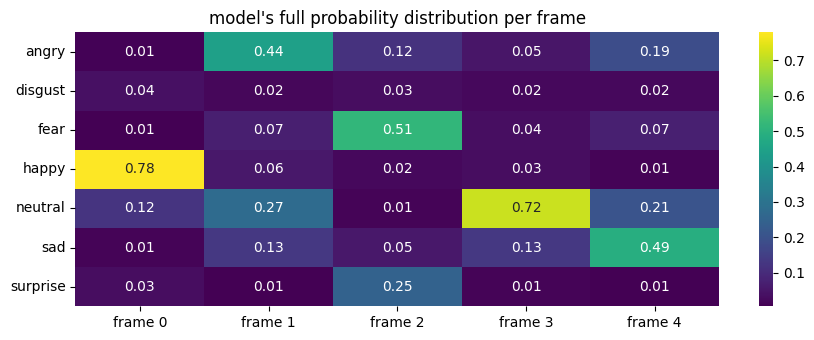

In [ ]:
import pandas as pd

entropy = -np.sum(prob_matrix * np.log(prob_matrix + 1e-12), axis=1)
margin = np.array([r["confidence"] - r["runner_up_confidence"] for r in results])

session_df = pd.DataFrame({
    "frame": range(len(results)),
    "prediction": [r["emotion"] for r in results],
    "confidence_%": [r["confidence"] for r in results],
    "runner_up": [r["runner_up"] for r in results],
    "runner_up_%": [r["runner_up_confidence"] for r in results],
    "margin_%": margin,
    "entropy_nats": entropy,
})
display(session_df.style.background_gradient(subset=["confidence_%"], cmap="Greens")
                          .background_gradient(subset=["entropy_nats"], cmap="Reds"))

plt.figure(figsize=(9, 3.5))
sns.heatmap(prob_matrix.T, annot=True, fmt=".2f", cmap="viridis",
            xticklabels=[f"frame {i}" for i in range(len(results))], yticklabels=classes)
plt.title("model's full probability distribution per frame")
plt.tight_layout(); plt.show()

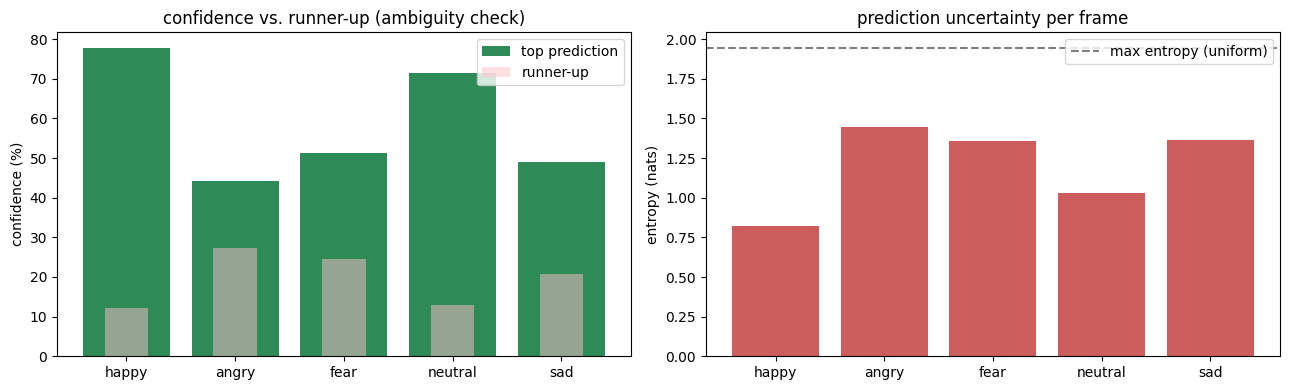

In [ ]:
x = np.arange(len(results))

fig, ax = plt.subplots(1, 2, figsize=(13, 4))

ax[0].bar(x, [r["confidence"] for r in results], color="seagreen", label="top prediction")
ax[0].bar(x, [r["runner_up_confidence"] for r in results], alpha=0.5, color="pink",
          width=0.4, label="runner-up")
ax[0].set_xticks(x); ax[0].set_xticklabels([r["emotion"] for r in results])
ax[0].set_ylabel("confidence (%)")
ax[0].set_title("confidence vs. runner-up (ambiguity check)")
ax[0].legend()

ax[1].bar(x, entropy, color="indianred")
ax[1].axhline(np.log(len(classes)), color="black", linestyle="--", alpha=0.5, label="max entropy (uniform)")
ax[1].set_xticks(x); ax[1].set_xticklabels([r["emotion"] for r in results])
ax[1].set_ylabel("entropy (nats)")
ax[1].set_title("prediction uncertainty per frame")
ax[1].legend()

plt.tight_layout(); plt.show()

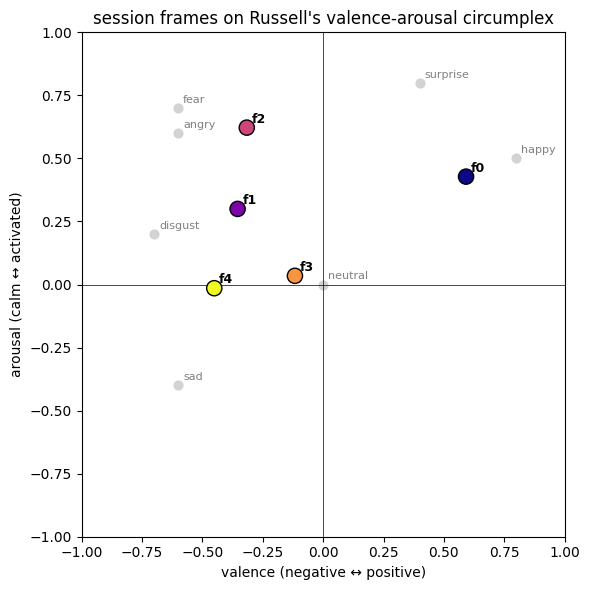

Positions the classifier's full predicted probability distribution within a standard
affective-science model (Russell, 1980) for descriptive purposes only — not a validated
measurement of the subject's psychological state.


In [ ]:
# Standard approximate coordinates used in affective-computing literature — this places the
# session within an established psychological model, it is not a clinical measurement.
va_map = {
    "happy":    (0.80,  0.50),
    "surprise": (0.40,  0.80),
    "neutral":  (0.00,  0.00),
    "sad":      (-0.60, -0.40),
    "fear":     (-0.60,  0.70),
    "angry":    (-0.60,  0.60),
    "disgust":  (-0.70,  0.20),
}
va_coords = np.array([va_map[c] for c in classes])
frame_va = prob_matrix @ va_coords  # probability-weighted position, not just the argmax label

plt.figure(figsize=(6, 6))
for c, (v, a) in va_map.items():
    plt.scatter(v, a, s=40, color="lightgray")
    plt.text(v + 0.02, a + 0.02, c, fontsize=8, color="gray")
plt.scatter(frame_va[:, 0], frame_va[:, 1], c=x, cmap="plasma", s=120, edgecolor="black", zorder=3)
for i, (v, a) in enumerate(frame_va):
    plt.text(v + 0.02, a + 0.02, f"f{i}", fontsize=9, fontweight="bold")
plt.axhline(0, color="black", lw=0.5); plt.axvline(0, color="black", lw=0.5)
plt.xlabel("valence (negative ↔ positive)")
plt.ylabel("arousal (calm ↔ activated)")
plt.title("session frames on Russell's valence-arousal circumplex")
plt.xlim(-1, 1); plt.ylim(-1, 1)
plt.tight_layout(); plt.show()

print("Positions the classifier's full predicted probability distribution within a standard")
print("affective-science model (Russell, 1980) for descriptive purposes only — not a validated")
print("measurement of the subject's psychological state.")

### Indicative Affective Indices (exploratory, non-diagnostic)

Rather than a fabricated 0-100 "risk score," each index is a **continuous, probability-weighted
projection** of the model's session output onto established affective-science constructs:

- **Negative Affect** — derived from PANAS (Watson, Clark & Tellegen, 1988), mapped to our 7 emotion
  classes' probability-weighted contribution to negative-affect terms (distressed, upset, afraid, hostile,
  nervous).
- **Arousal-weighted Distress** — combines Russell's (1980) valence/arousal circumplex position with
  negative valence, since sustained high-arousal negative states (fear/anger) are behaviorally distinct
  from low-arousal negative states (sadness).
- **Session Stability** — variance of valence across frames; a proxy for emotional volatility rather than
  any single state.

**Important limitation to state explicitly in the paper:** facial expression classification is not an
established measure of internal psychological state (see Barrett et al., 2019, for a review of this
evidence gap). These indices describe *what the classifier predicted from facial appearance*, not a
clinical assessment of stress, anxiety, or depression. With n=5 frames from one session, none of this
supports any individual-level claim.

In [ ]:
panas_negative_affect = {
    "angry": 0.9, "fear": 1.0, "sad": 0.7, "disgust": 0.5,
    "surprise": 0.1, "neutral": 0.0, "happy": -1.0,
}
na_weights = np.array([panas_negative_affect[c] for c in classes])

frame_negative_affect = prob_matrix @ na_weights          # continuous, unbounded-ish signal
frame_valence = frame_va[:, 0]                              # reuse from the circumplex cell
frame_arousal = frame_va[:, 1]
arousal_weighted_distress = np.clip(-frame_valence, 0, None) * (0.5 + 0.5 * np.clip(frame_arousal, -1, 1))

session_stability = float(np.std(frame_valence))

print(f"Mean negative affect (session):        {frame_negative_affect.mean():+.3f}")
print(f"Mean arousal-weighted distress:         {arousal_weighted_distress.mean():.3f}")
print(f"Session valence stability (std):        {session_stability:.3f}  (lower = more volatile)")
print(f"\nSample size: n={len(results)} frames — too small for any individual-level inference;")
print("shown here to demonstrate the pipeline, not as an assessment result.")

Mean negative affect (session):        +0.239
Mean arousal-weighted distress:         0.154
Session valence stability (std):        0.377  (lower = more volatile)

Sample size: n=5 frames — too small for any individual-level inference;
shown here to demonstrate the pipeline, not as an assessment result.


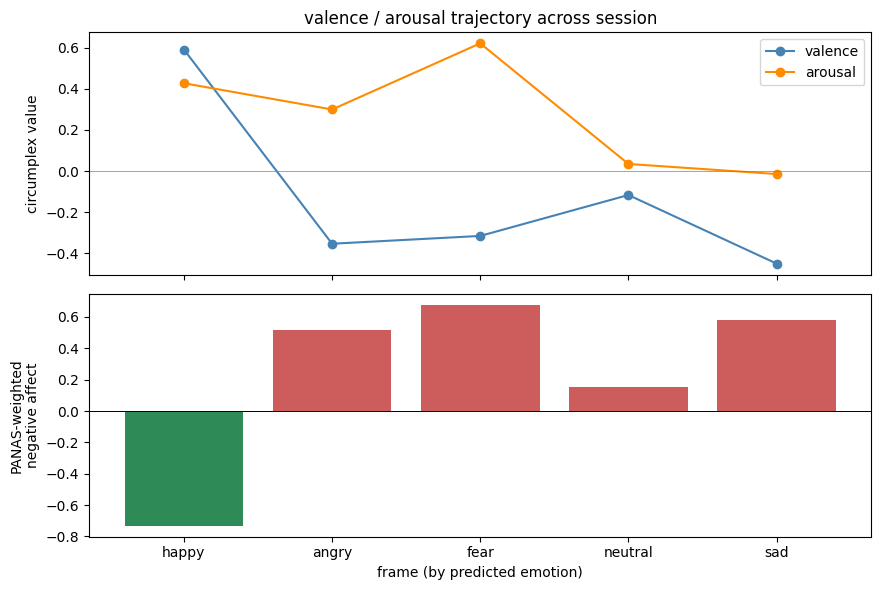

In [ ]:
fig, ax = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

ax[0].plot(x, frame_valence, marker="o", label="valence", color="steelblue")
ax[0].plot(x, frame_arousal, marker="o", label="arousal", color="darkorange")
ax[0].axhline(0, color="gray", lw=0.5)
ax[0].set_ylabel("circumplex value")
ax[0].legend(); ax[0].set_title("valence / arousal trajectory across session")

ax[1].bar(x, frame_negative_affect, color=["seagreen" if v < 0 else "indianred" for v in frame_negative_affect])
ax[1].axhline(0, color="black", lw=0.7)
ax[1].set_ylabel("PANAS-weighted\nnegative affect")
ax[1].set_xticks(x); ax[1].set_xticklabels([r["emotion"] for r in results])
ax[1].set_xlabel("frame (by predicted emotion)")

plt.tight_layout(); plt.show()

In [ ]:
print("=" * 52)
print("  EXPLORATORY AFFECTIVE-INDEX SUMMARY (research demo)")
print("=" * 52)
print(f"Frames analyzed:              {len(results)}")
print(f"Mean negative affect (PANAS): {frame_negative_affect.mean():+.3f}")
print(f"Mean distress (arousal-wtd):  {arousal_weighted_distress.mean():.3f}")
print(f"Valence volatility (std):     {session_stability:.3f}")
print("-" * 52)
print("These are continuous, exploratory signals derived entirely from facial-expression")
print("classifier output. They are NOT validated stress, anxiety, or depression measurements,")
print("are not clinically calibrated, and should not be interpreted as an assessment of any")
print("individual's mental health. See Barrett et al. (2019) for the broader evidence gap")
print("between facial expression and internal affective state. For any real concern about")
print("mental health, consult a qualified professional.")
print("=" * 52)

  EXPLORATORY AFFECTIVE-INDEX SUMMARY (research demo)
Frames analyzed:              5
Mean negative affect (PANAS): +0.239
Mean distress (arousal-wtd):  0.154
Valence volatility (std):     0.377
----------------------------------------------------
These are continuous, exploratory signals derived entirely from facial-expression
classifier output. They are NOT validated stress, anxiety, or depression measurements,
are not clinically calibrated, and should not be interpreted as an assessment of any
individual's mental health. See Barrett et al. (2019) for the broader evidence gap
between facial expression and internal affective state. For any real concern about
mental health, consult a qualified professional.
